# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(airbnb_filename)

df.head()

,name,description,neighborhood_overview,host_name,host_location,host_about,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications,price_category
0,Skylit Midtown Castle,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,Jennifer,"New York, New York, United States",A New Yorker since 2000! My passion is creatin...,0.80,0.17,True,8.0,...,4.86,4.41,False,3,3,0,0,0.33,9,low
1,"Whole flr w/private bdrm, bath & kitchen(pls r...","Enjoy 500 s.f. top floor in 1899 brownstone, w...",Just the right mix of urban center and local n...,LisaRoxanne,"New York, New York, United States",Laid-back Native New Yorker (formerly bi-coast...,0.09,0.69,True,1.0,...,4.71,4.64,False,1,1,0,0,4.86,6,low
2,"Spacious Brooklyn Duplex, Patio + Garden",We welcome you to stay in our lovely 2 br dupl...,NaN,Rebecca,"Brooklyn, New York, United States","Rebecca is an artist/designer, and Henoch is i...",1.00,0.25,True,1.0,...,4.50,5.00,False,1,1,0,0,0.02,3,high
3,Large Furnished Room Near B'way,Please don’t expect the luxury here just a bas...,"Theater district, many restaurants around here.",Shunichi,"New York, New York, United States",I used to work for a financial industry but no...,1.00,1.00,True,1.0,...,4.87,4.36,False,1,0,1,0,3.68,4,low
4,Cozy Clean Guest Room - Family Apt,"Our best guests are seeking a safe, clean, spa...",Our neighborhood is full of restaurants and ca...,MaryEllen,"New York, New York, United States",Welcome to family life with my oldest two away...,NaN,NaN,True,1.0,...,4.94,4.92,False,1,0,1,0,0.87,7,low


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

1. I chose the Airbnb data set.
2. The label is price_category. I am predicting whether the listing's price falls at or above 75th percentile (high), or not (low).
3. Some features that I plan to use are review_scores_value, host_is_superhost, room_type, bedrooms, amenities, and neighborhood_group_cleansed.
4. This problem matters because it will determine what locations that Trove Analytics wants to invest their money in. This means that my model's predictions on high valued properties can determine whether or not Trove Analytics purchases them.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

<AxesSubplot:xlabel='price_category', ylabel='Count'>

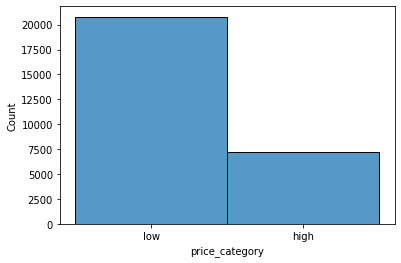

In [3]:
# histplot to see class distribution
sns.histplot(data=df, x=df['price_category'])

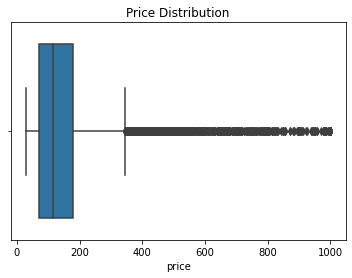

In [4]:
# boxplot to see outliers
sns.boxplot(x=df['price'])
plt.title('Price Distribution')
plt.show()

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [5]:
df.describe(include='all')

,name,description,neighborhood_overview,host_name,host_location,host_about,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications,price_category
count,28017,27452,18206,28022,27962,17077,16179.000000,16909.000000,28022,28022.000000,...,28022.000000,28022.000000,28022,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022
unique,27386,25952,15800,7566,1364,11962,NaN,NaN,1,NaN,...,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,2
top,Water View King Bed Hotel Room,Welcome to UNTITLED (Adj.) at 3 Freeman Alley!...,We're located in a safe and quiet residential ...,Karen,"New York, New York, United States",I’m a New York native that loves to eat & enjo...,NaN,NaN,True,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,low
freq,27,61,34,246,16059,191,NaN,NaN,28022,NaN,...,NaN,NaN,20382,NaN,NaN,NaN,NaN,NaN,NaN,20785
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.906901,0.791953,NaN,14.554778,...,4.750393,4.647670,NaN,9.581900,5.562986,3.902077,0.048283,1.758325,5.169510,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,0.227282,0.276732,NaN,120.721287,...,0.415717,0.518023,NaN,32.227523,26.121426,17.972386,0.442459,4.446143,2.028497,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,0.000000,...,0.000000,0.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.010000,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.940000,0.680000,NaN,1.000000,...,4.670000,4.550000,NaN,1.000000,0.000000,0.000000,0.000000,0.130000,4.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.910000,NaN,1.000000,...,4.880000,4.780000,NaN,1.000000,1.000000,0.000000,0.000000,0.510000,5.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,3.000000,...,5.000000,5.000000,NaN,3.000000,1.000000,1.000000,0.000000,1.830000,7.000000,NaN


all columns:
 ['name', 'description', 'neighborhood_overview', 'host_name', 'host_location', 'host_about', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_listings_count', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_group_cleansed', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable', 'calculated_host_listings_count', 'calculated_host_listings_count_ent

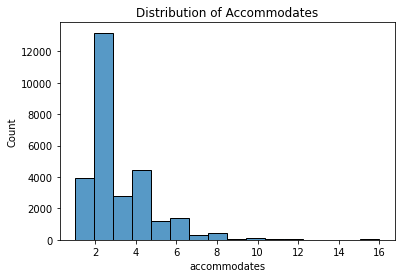

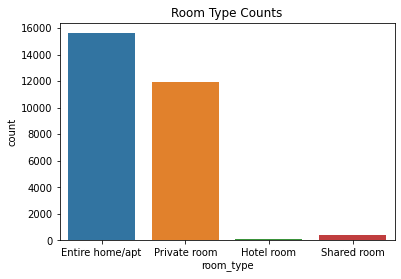

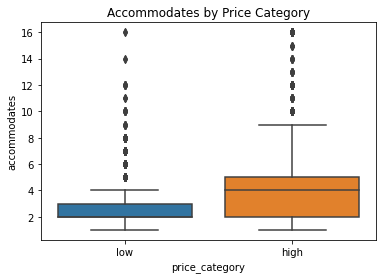

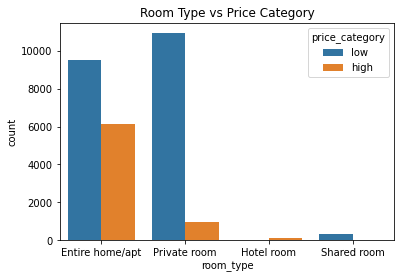

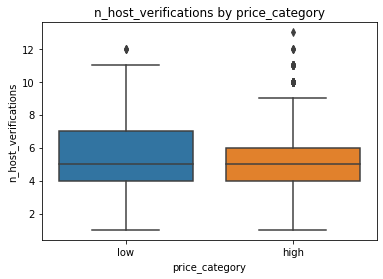

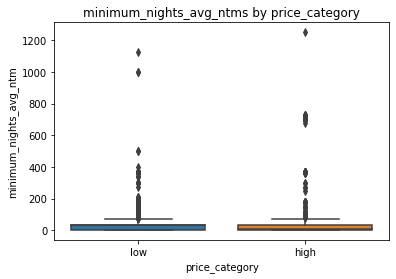

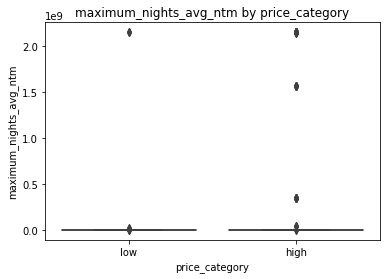

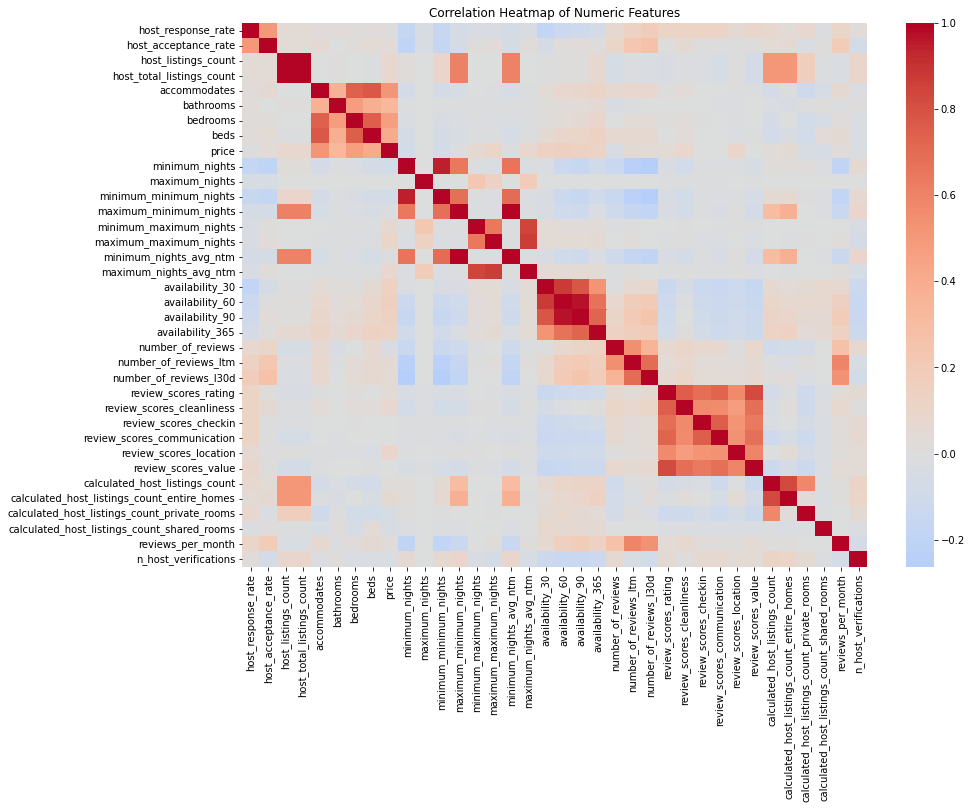

                             review_scores_rating  review_scores_cleanliness  \
review_scores_rating                     1.000000                   0.758213   
review_scores_cleanliness                0.758213                   1.000000   
review_scores_checkin                    0.688152                   0.571335   
review_scores_communication              0.727749                   0.567027   
review_scores_location                   0.574464                   0.480354   
review_scores_value                      0.820631                   0.687473   

                             review_scores_checkin  \
review_scores_rating                      0.688152   
review_scores_cleanliness                 0.571335   
review_scores_checkin                     1.000000   
review_scores_communication               0.756146   
review_scores_location                    0.528719   
review_scores_value                       0.644369   

                             review_scores_communication  \


In [6]:
# print all column names
print('all columns:\n', df.columns.tolist())

# computer the number of nan values in each column
nan_count = np.sum(df.isnull(), axis=0)

# print column names that have nan values
condition = nan_count != 0 # look for all columns with missing values
nan_cols = nan_count[condition].index.tolist()
print('\nnan columns:\n', nan_cols)

# print types of columns that have nan values
nan_cols_types = df[nan_cols].dtypes
print('\nnan columns types:\n', nan_cols_types)

# print counts of nan values per column with at least one
print('\nnan columns nan counts:\n', nan_count[nan_cols])

# print unique value counts of all columns
unique_counts = df.nunique().sort_values()
print('\nunique value counts:\n', unique_counts)

# histplot to see distribution in 'accommodates'
sns.histplot(df['accommodates'], bins=16)
plt.title('Distribution of Accommodates')
plt.show()

# categorigal bar chart to see distribution in 'room_type'
sns.countplot(x=df['room_type'])
plt.title('Room Type Counts')
plt.show()

# view if 'accomodates' has a relationship with 'price_category'
sns.boxplot(x='price_category', y='accommodates', data=df)
plt.title('Accommodates by Price Category')
plt.show()

# view if 'room_type' has a relationship with 'price_category'
sns.countplot(x='room_type', hue='price_category', data=df)
plt.title('Room Type vs Price Category')
plt.show()

# view if 'n_host_verifications' has a relationship with 'price_category'
sns.boxplot(x='price_category', y='n_host_verifications', data=df)
plt.title('n_host_verifications by price_category')
plt.show()

# view if 'minimum_nights_avg_ntm' has a relationship with 'price_category'
sns.boxplot(x='price_category', y='minimum_nights_avg_ntm', data=df)
plt.title('minimum_nights_avg_ntms by price_category')
plt.show()

# view if 'maximum_nights_avg_ntm' has a relationship with 'price_category'
sns.boxplot(x='price_category', y='maximum_nights_avg_ntm', data=df)
plt.title('maximum_nights_avg_ntm by price_category')
plt.show()


# correlation heatmap for numeric features
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

# check review_scores columns specifically for multicollinearity
review_cols = ['review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin',
               'review_scores_communication', 'review_scores_location', 'review_scores_value']
print(df[review_cols].corr())

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

Missing Values:
There are nine columns with missing values. Five of them are of type object. Name and host_location likely will not make meaningful contributions to the model. Description, neighborhood_overview, and host_about may be beneficial if converted into missing value indicators (i.e. has_description, has_neighborhood_overview, and has_host_about), but that may go beyond the scope of this course, so I will likely not use these columns in my model since they are open ended. Locations with more bedrooms likely cost more, so I may want to convert that using one-hot encoding. The other numeric columns with missing values are host_acceptance_rate, bedrooms, and beds. I will likely impute these using the median since all three are right-skewed.


Outliers:
There are several columns that appear to have outliers. Here are a few examples:
* host_listings_count
* minimum_nights
* calculated_host_listings_count
* reviews_per_month.

For these columns, I will likely winsorize them or apply a log transformation.


Redundant Columns:
It appears that there are some columns that serve the same, similar, or redundant purposes. Here are a few examples:
* 'host_listings_count' and 'host_total_listings_count'
* 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', and 'maximum_nights_avg_ntm'.
* 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', and 'calculated_host_listings_count_shared_rooms'


Irrelevant Columns:
* Columns with one value: host_is_superhost, host_has_profile_pic, host_identity_verified
* Open ended columns: name, description, neighborhood_overview, host_name, host_location, host_about, amenities
    * May be able to keep amenities by using one-hot encoding for key words
    
Class Imbalance:
The label 'price_category' is imbalanced. Almost 3/4 of the listings fall into the 'low' category, with the remaining 1/4 in the 'high' category. I may want to do random sampling in order to get even distributions or making sure I am using weights for classes.

Feature-Label Relationship:
'accommodates' and 'room_type' both show a relationship with price_category. In the accommodates vs. price_category boxplot, 'high' price listings have a noticeably higher median (4) and Q3  (9) for accommodates compared to 'low' price listings with a median of 2 and a Q3 of 4. The room_type vs. price_category plot shows 'Private' rooms skew heavily toward low price point, while 'Entire home/apt' is closer to evenly split. 'n_host_verifications' does not appear to have much of a relationship with 'price_category'. 'minimum_nights_avg_ntms' and 'maximum_nights_avg_ntms' appear to have little relationship with 'price_category'.

Multicollinearity:
The correlation heatmap shows that 'review_scores_rating' is highly correlated with the other review_scores columns (cleanliness, check, communication, location, and value). Since I am using logistic regression, I will drop 'review_scores_rating' and keep the more specific sub-category scores.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

1. The Airbnb dataset was taken from people who have used Airbnb in the past. This means that it excludes people who cannot afford to rent properties on Airbnb, which may cause the dataset to underepresent lower-income individuals and communities. The data also reflects whatever biases exist in Airbnb's current system. The following are some features that could serve as proxies for protected characteristics:
* neighbourhood_group_cleansed: can serve as a proxy for socioeconomic status and potentially race or ethnicity due to historical housing segregation
* host_name: could allow inference of a host's gender or ethnicity
* host_about and host_location: could reveal information about a host's background, language, or national origin

2. Hosts with properties in lower-income neighborhoods or neighborhoods with a high minority population could be systematically predicted into the 'low' price category, regardless of the actual quality of their listing. This would disproportionately harm hosts who are already at an economic disadvantage. The model could indirectly discriminate against minority hosts by consistently undervaluing their properties. Mispredicting a 'low' price could cause guests to overpay for a worse experience, while mispredicting a 'high' price could cause a host to lose potential bookings.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [7]:
import scipy.stats as stats

In [8]:
# drop 'price' and irrelevant columns
irr_cols = ['price', 'name', 'n_host_verifications', 'description', 'neighborhood_overview', 'host_name', 'host_location', 'host_about', 'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
            'minimum_nights_avg_ntm', 'minimum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights',
            'maximum_nights_avg_ntm', 'maximum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights',
            'review_scores_rating'
           ]
df_prep = df.drop(columns=irr_cols)

# make amentities_count column
df_prep['amenities_count'] = df['amenities'].apply(lambda x: len(x.split(',')) if isinstance(x, str) and x not in ['[]', ''] else 0)

# one-hot encode for some key amenities
key_amenities = ['Pool', 'Air conditioning', 'TV', 'Elevator', 'Gym', 'Wifi']
for amenity in key_amenities:
    col_name = f'has_{amenity.lower().replace(" ", "_")}'
    df_prep[col_name] = df['amenities'].str.contains(amenity, case=False, na=False).astype(int)
# drop original 'amenities' column
df_prep = df_prep.drop(columns=['amenities'])

# drop reduntant columns, keeping only one from each category if relevant
# keep: calculated_host_listings_count, availability_365, number_of_reviews
redundant_cols = ['host_total_listings_count', 'host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms',
                  'availability_30', 'availability_60', 'availability_90',
                  'number_of_reviews_ltm', 'number_of_reviews_l30d',
                 ]
df_prep = df_prep.drop(columns=redundant_cols)

# handle numeric missing values using median
numeric_missing = ['host_response_rate', 'host_acceptance_rate', 'bedrooms', 'beds']
for col in numeric_missing:
    df_prep[col] = df_prep[col].fillna(df_prep[col].median())

# handle outliers using winsorization
skewed_cols = ['calculated_host_listings_count', 'reviews_per_month']
for col in skewed_cols:
    df_prep[col] = np.array(stats.mstats.winsorize(df_prep[col], limits=[0.01, 0.01]))

# encode categorical features
categorical_cols = ['neighbourhood_group_cleansed', 'room_type']
df_prep = pd.get_dummies(df_prep, columns=categorical_cols, drop_first=True)

# encode boolean features
bool_cols = ['has_availability', 'instant_bookable']
for col in bool_cols:
    df_prep[col] = df_prep[col].astype(int)

# convert label to binary (high=True, low=False)
df_prep['price_category'] = np.where(df_prep['price_category'] == 'high', 1, 0)

# scale numeric columns using z-score
numeric_cols = ['host_response_rate', 'host_acceptance_rate', 'accommodates', 'bathrooms',
                'bedrooms', 'beds', 'availability_365', 'number_of_reviews',
                'review_scores_cleanliness', 'review_scores_checkin',
                'review_scores_communication', 'review_scores_location',
                'review_scores_value', 'calculated_host_listings_count',
                'reviews_per_month', 'amenities_count']
df_prep[numeric_cols] = df_prep[numeric_cols].apply(stats.zscore)

# confirm no missing values remain
print('remaining missing values:', df_prep.isnull().sum().sum())
print('shape:', df_prep.shape)
df_prep.head()


remaining missing values: 0
shape: (28022, 32)


,host_response_rate,host_acceptance_rate,accommodates,bathrooms,bedrooms,beds,has_availability,availability_365,number_of_reviews,review_scores_cleanliness,...,has_elevator,has_gym,has_wifi,neighbourhood_group_cleansed_Brooklyn,neighbourhood_group_cleansed_Manhattan,neighbourhood_group_cleansed_Queens,neighbourhood_group_cleansed_Staten Island,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,-0.818339,-3.004607,-1.007673,-0.337606,-0.440314,-0.555409,1,1.494669,0.291485,0.011584,...,0,0,1,0,1,0,0,0,0,0
1,-4.791198,-0.668378,0.067470,-0.337606,-0.440314,1.298622,1,0.458908,6.703791,-0.214944,...,0,0,1,1,0,0,0,0,0,0
2,0.300776,-2.645187,0.605041,0.849692,1.050381,0.371607,1,-0.051779,-0.525595,0.673742,...,0,0,1,1,0,0,0,0,0,0
3,0.300776,0.724374,-0.470102,-0.337606,-0.440314,-0.555409,1,0.444523,8.444528,-1.539261,...,0,0,1,0,1,0,0,0,1,0
4,0.300776,0.320027,-1.007673,-0.337606,-0.440314,-0.555409,1,-0.936492,1.534869,0.360088,...,1,0,1,0,1,0,0,0,1,0


### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

Irrelevant Columns:
* 'price' - 'price_category' was directly derived from 'price', cannot use this as a feature
* 'name', 'description', 'neighborhood_overview', 'host_name', 'host_location', 'host_about': free-form text with no consistent structure
* 'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified': only one unique value in each
* 'n_host_verifications': near zero correlation with label
* 'minimum_nights_avg_ntm', 'minimum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights': near zero correlation with label and redundant
* 'maximum_nights_avg_ntm', 'maximum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights':  near zero correlation with label and redundant
* 'review_scores_rating': high correlation with other review_score columns

Amenities Columns:
* added an 'amenities_count' column using 'amenities'
* one-hot encoded for key elements of 'amenities' that may hold a predictive value
* dropped original 'amenities' column

Redundant Columns:
* kept one representative column from each group:
    1. 'calculated_host_listings_count': verified count of host listings by Airbnb
    2. 'availability_365': captures same info in more complete time window, less sensitive to short-term fluctuations
    3. 'number_of_reviews': captures same info in more complete time window, less sensitive to short-term fluctuations
* dropped remaining redundant columns:
    1. 'host_total_listings_count', 'host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms'
    2. 'availability_30', 'availability_60', 'availability_90'
    3. 'number_of_reviews_ltm', 'number_of_reviews_l30d'

Columns with Missing Values:
* 'host_response_rate', 'host_acceptance_rate', 'bedrooms', 'beds': imputed missing values using the median

Winsorized Columns With Many Outliers:
* 'calculated_host_listings_count', 'reviews_per_month': winsorized using the 1st & 99th percentiles

Categorical Columns:
* 'neighbourhood_group_cleansed', 'room_type': one-hot encoded, then dropped original columns

Boolean Columns:
* 'has_availability', 'instant_bookable': converted to binary

Label:
* 'price_category': converted to binary (high=1, low=0)

Scale Numeric Columns:
* 'host_response_rate', 'host_acceptance_rate', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'availability_365', 'number_of_reviews', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'reviews_per_month', 'amenities_count': applied z-score standardization to all the continuous numeric columns left in the dataset

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [9]:
# Create labeled examples from the dataset
X = df_prep.drop(columns='price_category')
y = df_prep['price_category']

In [10]:
# Create training and test sets out of the labeled examples 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=1234)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (21016, 31)
X_test shape: (7006, 31)
y_train shape: (21016,)
y_test shape: (7006,)


In [11]:
# Train, test and evaluate your model
model = LogisticRegression(class_weight='balanced', max_iter=3000)
model.fit(X_train, y_train)

class_label_predictions = model.predict(X_test)

acc_score = accuracy_score(y_test, class_label_predictions)
f1 = f1_score(y_test, class_label_predictions, average='binary')

print('Baseline Logistic Regression Accuracy:', acc_score)
print('Baseline Logistic Regression F1 Score:', f1)

Baseline Logistic Regression Accuracy: 0.7590636597202398
Baseline Logistic Regression F1 Score: 0.6268788682581786


In [12]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
cs=[10**i for i in range(-5,5)]
param_grid = {'C': cs, 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}

grid_search = GridSearchCV(model, param_grid, scoring='f1', cv=5)
grid_search.fit(X_train, y_train)

print('Best hyperparameters:', grid_search.best_params_)
print('Best cross-validation F1 score:', grid_search.best_score_)

Best hyperparameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation F1 score: 0.6367447086866496


In [13]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
best_model = grid_search.best_estimator_

final_predictions = best_model.predict(X_test)

final_acc_score = accuracy_score(y_test, final_predictions)
final_f1 = f1_score(y_test, final_predictions, average='binary')

print('Before Tuning')
print('Accuracy:', acc_score)
print('F1 Score:', f1)

print('\nAfter Tuning')
print('Accuracy:', final_acc_score)
print('F1 Score:', final_f1)



Before Tuning
Accuracy: 0.7590636597202398
F1 Score: 0.6268788682581786

After Tuning
Accuracy: 0.7590636597202398
F1 Score: 0.6268788682581786


In [14]:
from sklearn.metrics import precision_recall_curve

In [15]:
# tune the classification threshold using TRAINING data
train_probs = best_model.predict_proba(X_train)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_train, train_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_threshold = thresholds[np.argmax(f1_scores)]
print('Best threshold:', best_threshold)

# apply threshold to the TEST set for final, unbiased evaluation
test_probs = best_model.predict_proba(X_test)[:, 1]
threshold_predictions = (test_probs >= best_threshold).astype(int)
threshold_acc = accuracy_score(y_test, threshold_predictions)
threshold_f1 = f1_score(y_test, threshold_predictions, average='binary')

print('\nBefore Threshold Tuning')
print('Accuracy:', final_acc_score)
print('F1 Score:', final_f1)

print('\nAfter Threshold Tuning')
print('Accuracy:', threshold_acc)
print('F1 Score:', threshold_f1)

Best threshold: 0.5584262502528511

Before Threshold Tuning
Accuracy: 0.7590636597202398
F1 Score: 0.6268788682581786

After Threshold Tuning
Accuracy: 0.7790465315443905
F1 Score: 0.6287769784172663


Top 5 most influential features: ['neighbourhood_group_cleansed_Manhattan', 'room_type_Hotel room', 'neighbourhood_group_cleansed_Staten Island', 'room_type_Shared room', 'room_type_Private room']
                                          name       imp
25      neighbourhood_group_cleansed_Manhattan  1.905118
28                        room_type_Hotel room  1.281434
27  neighbourhood_group_cleansed_Staten Island -1.249923
30                       room_type_Shared room -1.211116
29                      room_type_Private room -1.189274


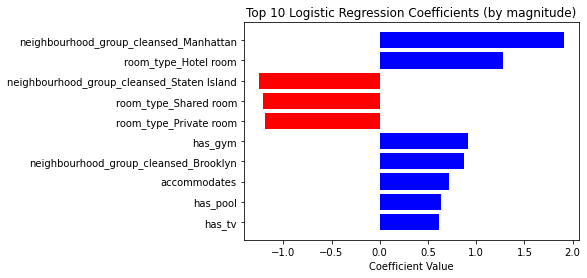

In [16]:
# Interpret your model's outputs
# get coefficients for each feature
feature_imp = best_model.coef_[0]

# create a dataframe of feature names and their coefficients
df_features = pd.DataFrame({'name': X_train.columns.values, 'imp': feature_imp})

# sort by absolute value of coefficient, descending
df_sorted = df_features.reindex(df_features['imp'].abs().sort_values(ascending=False).index)

# extract top 5 feature names
top_five = df_sorted.iloc[:5]['name'].tolist()
print('Top 5 most influential features:', top_five)
print(df_sorted.head(5))

# plot top 10 coefficients by absolute value
top_ten = df_sorted.iloc[:10]
colors = ['red' if v < 0 else 'blue' for v in top_ten['imp']]
plt.barh(top_ten['name'], top_ten['imp'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Top 10 Logistic Regression Coefficients (by magnitude)')
plt.gca().invert_yaxis()
plt.show()

### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1. I chose logistic regression because this is a binary classification problem, and logistic regression handles binary outcomes well. Logistic regression also produces interpretable coefficients. This makes it easier to explain which features drive predictions to Trove Analytics.
2. When I did grid search, the performance of the tuned model was nearly identical to the untuned version. Both had an accuracy of 0.7590636597202398 and F1 score of 0.6268788682581786. This is because the default hyperparameters were already near-optimal. I found that tuning the classification threshold was a more useful mechanism for improving F1 given the class imbalance. I selected the threshold using only the training set.
3. The top 5 features were 'neighbourhood_group_cleansed_Manhattan', 'room_type_Hotel room', 'neighbourhood_group_cleansed_Staten Island', 'room_type_Shared room', and 'room_type_Private room'. Manhattan listings and hotel rooms are strongly associated with high prices. Staten Island listings, shared rooms, and private rooms are strongly associated with low prices.
4. There are some fairness and ethical concerns with my model. 'neighbourhood_group_cleansed' was the strongest predictor, but location can act as a proxy for socioeconomic status as well as, in some cases, race or ethnicity. This means that my model relies heavily on where a listing is rather than its actual qualities. This could cause it to systematically undervalue listings in lower-income or minority-majority neighborhoods undeservingly. This could reduce investment interest in those areas regardless of listing quality, disproportionately harming hosts there. 

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [17]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [19]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
input_layer = keras.layers.InputLayer(input_shape=n_features)
nn_model.add(input_layer)

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Add a comment explaining your choices.

hidden_layer_1 = keras.layers.Dense(units=16, activation='relu')
nn_model.add(hidden_layer_1)

hidden_layer_2 = keras.layers.Dense(units=8, activation='relu')
nn_model.add(hidden_layer_2)

# 2 hidden layers: enough to caputre the non-linear patterns without overfitting
# decrease by factor of 2 for units: starting at 8 units and narrowing down lets the model narrow from abstract to more compact before the output layer
    # tested with 16 and 8 units, led to overfitting, switched to 8 and 4 units respectively
# ReLU activation function: trains efficiently, avoids vanishing gradient issues that sigmoid/tanh can cause


# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
output_layer = keras.layers.Dense(units=1, activation='sigmoid')
nn_model.add(output_layer)

# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 16)                512       
_________________________________________________________________
dense_1 (Dense)              (None, 8)                 136       
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 9         
Total params: 657
Trainable params: 657
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [20]:
# Decision: What learning rate will you use? Add a comment explaining your decision.

sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)
# learning_rate=0.01: small enough to avoid overshooting the minimum, large enough to converge in a reasonable number of epochs

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [21]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [22]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [23]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [24]:
# Decision: How many epochs?
# num_epochs = 100: gives the model enough passes over the training data to converge without overfitting

t0 = time.time() # start time

num_epochs = 30

history = nn_model.fit(X_train_scaled, y_train, epochs=num_epochs, validation_split=0.2, verbose=0, callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=5)])

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [5/ 30], Loss: 0.3932, Accuracy: 0.8160, Val_loss: 0.3925, Val_accuracy: 0.8149
Epoch [10/ 30], Loss: 0.3742, Accuracy: 0.8249, Val_loss: 0.3782, Val_accuracy: 0.8197
Epoch [15/ 30], Loss: 0.3642, Accuracy: 0.8317, Val_loss: 0.3703, Val_accuracy: 0.8240
Epoch [20/ 30], Loss: 0.3579, Accuracy: 0.8363, Val_loss: 0.3655, Val_accuracy: 0.8254
Epoch [25/ 30], Loss: 0.3538, Accuracy: 0.8374, Val_loss: 0.3617, Val_accuracy: 0.8280
Epoch [30/ 30], Loss: 0.3502, Accuracy: 0.8393, Val_loss: 0.3595, Val_accuracy: 0.8290
Elapsed time: 71.04s


### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



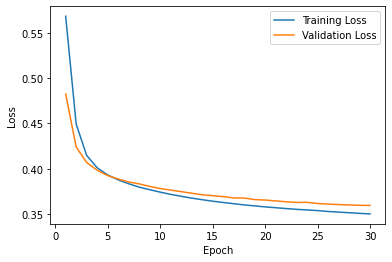

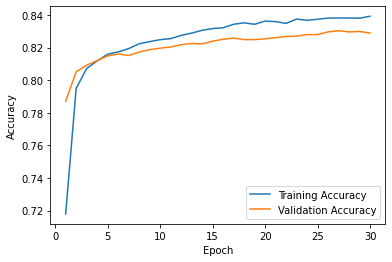

In [25]:
# Plot training loss and validation loss over epochs
plt.plot(range(1, num_epochs+1), history.history['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training accuracy and validation accuracy over epochs
plt.plot(range(1, num_epochs+1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, num_epochs+1), history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [26]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

probability_predictions = nn_model.predict(X_test_scaled)
class_label_predictions = (probability_predictions >= 0.5).astype(int)

In [27]:
# Compute accuracy and F1 score for the neural network and print the results

nn_test_accuracy = accuracy_score(y_test, class_label_predictions)
nn_test_f1 = f1_score(y_test, class_label_predictions)

print("Neural Network Test Accuracy: ", nn_test_accuracy)
print("Neural Network Test F1 Score: ", nn_test_f1)

Neural Network Test Accuracy:  0.8330002854695975
Neural Network Test F1 Score:  0.6404425322679779


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1. I used 2 hidden layers of 16 and 8 units with ReLU activation, with a sigmoid output layer for binary classification. I tried a smaller version with 8 and 4 units, but it slightly underfit, so I went back to 16 and 8 units. I used SGD with a learning rate of 0.01 because I thought it was a good standard default. I trained the model for 30 epochs. I initiall used 100 epochs, but the validation curves showed the model converged by 20-30 epochs, so more epochs was just wasted time without improving results.
2. When I used 100 epochs for 16 and 8 units, I saw mild overfitting, where the training accuracy kept rising while the validation accuracy stayed flat. Shrinking the number of units to 8 and 4 reduced the gap but caused underfitting, as the training accuracy lowered. Going back to 16 and 8 units, I used only 30 epochs to fix the issues. This gave me a small training accuracy and validation accuracy gap and stable metrics by the final epochs.
3. The test set gave an accuracy of about 83.30% and F1 score of 64.04%. The accuracy matched what the training curves predicted. The F1 score was lower than expected, likely due to class imbalance. 

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [29]:
# Build a side-by-side comparison of your two models using the metric variables
# you created.

results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Logistic Regression': [threshold_acc, threshold_f1],
    'Neural Network': [nn_test_accuracy, nn_test_f1]
})
print(results.to_string(index=False))

   Metric  Logistic Regression  Neural Network
 Accuracy             0.779047        0.833000
 F1 Score             0.628777        0.640443


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1. The neural network outperformed the logistic regression model on both metrics. Accuracy improved from 77.90% to 83.30% (about 5.4 percentage points), and F1 score improved from 62.88% to 64.04% (about 1.2 percentage points). The F1 improvement was much smaller than the accuracy improvement.
2. The added complexity was particially worth it. If the Trove Analytics needed faster results or results that are easier to interpret, the logistic regression is the better option. If those factors are not so important to Trove Analytics and accuracy is more important, the neural network is the better option. Logistic regression may be better in this case because Trove Analytics will likely want to understand why the model is making the decisions that it does.
3. If I were presenting this to Trove Analytics, I would recommend logistic regression. This is because logistic regression allows for interpretability, which would be important given that Trove Analytics will want to understand and trust the model's reasoning before making decisions involving real money. This will also allow us to interpret the output to see if any bias is present. Also, a false positive is worse than a false negative because a false positive means Trove Analytics loses money. Given that the F1 scores of both models are fairly close, logistic regression doesn't sacrifice much recall, which is important here. Further, logistic regression is faster and simplier.
4. If I had more time, I would do more feature engineering to gain more predictive variables that may have a strong effect on the label. I would also double check with my client whether they want to avoid false negatives or false positives. Perhaps I would also try out a decision tree and compare it to my other models.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1. I used AI tools whenever I got stuck during this capstone, which was very useful in helping me optimize the logistic regression model. Sometimes it was difficult to interpret why I was getting a low accuracy score. Inputting my methodology and results into AI helped me understand the best steps to take to improve my model. I also pasted my code into AI when I had a small error such as a typo I could not easily spot, which was very efficient.
2. Performing feature selection required the most thought for me. There were so many features to choose from, so I used AI to recommend tests for me to perform on the data to see which features I should keep, and which I should not. One prompt that worked well was after an AI recommended that I drop the 'amenities' "isn't amenities relevant?" The prompt was helpful because it showed that it is right to push back sometimes on AI because it is not always right. Some of the new columns that I made that were based on the 'amenities' column were of the most influential on the label.
3. I verified that my work was correct by visualizing the results and seeing if it looked appropriate. When I was still unsure, I would give a part that I was was unsure about to an AI tool and ask if I am making any mistakes.
4. One thing I would do differently next time is do more testing on the features before deleting some of them. For instance, for columns that are similar to one another, I would see which one has the strongest effect on the output before deciding which one to keep and which ones to delete.